

# **Import libraries and files** 💾



In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler #, StandardScaler, RobustScaler, QuantileTransformer, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn import set_config
set_config(transform_output='pandas')

In [ ]:
spotify_df = pd.read_csv("spotify_5000_songs.csv")
spotify_df

## **EDA**

In [ ]:
spotify_df.columns = spotify_df.columns.str.strip()
spotify_df

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.6580,0.25900,11,-13.141,0,0.0705,0.694,0.000059,0.9750,0.3060,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.7420,0.39900,2,-12.646,1,0.0346,0.217,0.000002,0.1070,0.6930,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.8510,0.73000,2,-11.048,1,0.3470,0.453,0.000063,0.1240,0.9050,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.7050,0.05020,4,-18.115,1,0.0471,0.879,0.000041,0.3860,0.5240,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.6510,0.11900,6,-19.807,1,0.0380,0.916,0.000343,0.1040,0.4020,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5230,5230,"1812 Festival Overture, Op. 49: 1812 Overture,...",Pyotr Ilyich Tchaikovsky,0.2020,0.06940,3,-23.390,1,0.0473,0.917,0.715000,0.0832,0.0655,87.906,,995000,4,1aEhYlZtypmipA06SDJ4U3,https://open.spotify.com/track/1aEhYlZtypmipA0...
5231,5231,"Winter Fragments pour ensemble instrumental, s...",Tristan Murail,0.1880,0.10100,6,-21.873,1,0.0442,0.855,0.426000,0.0694,0.0355,83.134,,855000,4,1Gfqe7TAKklmuZf6hxsH6h,https://open.spotify.com/track/1Gfqe7TAKklmuZf...
5232,5232,"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3...",Arnold Schoenberg,0.0596,0.00093,9,-42.959,1,0.0434,0.951,0.969000,0.0772,0.0344,71.573,,238187,3,2XNwnFrdMDpismp0VUZ7cU,https://open.spotify.com/track/2XNwnFrdMDpismp...
5233,5233,"Serenade For Strings In E, Op.22, B. 52: 1. Mo...",Antonín Dvořák,0.1330,0.02080,4,-29.443,1,0.0419,0.883,0.505000,0.1110,0.0591,67.109,,314307,4,7ucDwgMtE3YJtEfTbuRhy0,https://open.spotify.com/track/7ucDwgMtE3YJtEf...


In [ ]:
spotify_df.columns.str.strip()

Index(['Unnamed: 0', 'name', 'artist', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'type', 'duration_ms', 'time_signature',
       'id', 'html'],
      dtype='object')

In [ ]:
spotify_df.info()
spotify_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5235 entries, 0 to 5234
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5235 non-null   int64  
 1   name              5235 non-null   object 
 2   artist            5235 non-null   object 
 3   danceability      5235 non-null   float64
 4   energy            5235 non-null   float64
 5   key               5235 non-null   int64  
 6   loudness          5235 non-null   float64
 7   mode              5235 non-null   int64  
 8   speechiness       5235 non-null   float64
 9   acousticness      5235 non-null   float64
 10  instrumentalness  5235 non-null   float64
 11  liveness          5235 non-null   float64
 12  valence           5235 non-null   float64
 13  tempo             5235 non-null   float64
 14  type              5235 non-null   object 
 15  duration_ms       5235 non-null   int64  
 16  time_signature    5235 non-null   int64  


,0
Unnamed: 0,0
name,0
artist,0
danceability,0
energy,0
key,0
loudness,0
mode,0
speechiness,0
acousticness,0


In [ ]:
spotify_df = spotify_df.drop_duplicates(subset=['name', 'artist'], keep='first')
spotify_df

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.6580,0.25900,11,-13.141,0,0.0705,0.694,0.000059,0.9750,0.3060,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.7420,0.39900,2,-12.646,1,0.0346,0.217,0.000002,0.1070,0.6930,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.8510,0.73000,2,-11.048,1,0.3470,0.453,0.000063,0.1240,0.9050,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.7050,0.05020,4,-18.115,1,0.0471,0.879,0.000041,0.3860,0.5240,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.6510,0.11900,6,-19.807,1,0.0380,0.916,0.000343,0.1040,0.4020,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5230,5230,"1812 Festival Overture, Op. 49: 1812 Overture,...",Pyotr Ilyich Tchaikovsky,0.2020,0.06940,3,-23.390,1,0.0473,0.917,0.715000,0.0832,0.0655,87.906,,995000,4,1aEhYlZtypmipA06SDJ4U3,https://open.spotify.com/track/1aEhYlZtypmipA0...
5231,5231,"Winter Fragments pour ensemble instrumental, s...",Tristan Murail,0.1880,0.10100,6,-21.873,1,0.0442,0.855,0.426000,0.0694,0.0355,83.134,,855000,4,1Gfqe7TAKklmuZf6hxsH6h,https://open.spotify.com/track/1Gfqe7TAKklmuZf...
5232,5232,"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3...",Arnold Schoenberg,0.0596,0.00093,9,-42.959,1,0.0434,0.951,0.969000,0.0772,0.0344,71.573,,238187,3,2XNwnFrdMDpismp0VUZ7cU,https://open.spotify.com/track/2XNwnFrdMDpismp...
5233,5233,"Serenade For Strings In E, Op.22, B. 52: 1. Mo...",Antonín Dvořák,0.1330,0.02080,4,-29.443,1,0.0419,0.883,0.505000,0.1110,0.0591,67.109,,314307,4,7ucDwgMtE3YJtEfTbuRhy0,https://open.spotify.com/track/7ucDwgMtE3YJtEf...


In [ ]:
spotify_df = spotify_df.set_index('name')

In [ ]:
spotify_df = spotify_df.drop(columns=['Unnamed: 0', 'duration_ms', 'time_signature', 'key', 'mode'])
spotify_df

,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,html
name,,,,,,,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.6580,0.25900,-13.141,0.0705,0.694,0.000059,0.9750,0.3060,110.376,,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
Saudade De Bahia,Antônio Carlos Jobim,0.7420,0.39900,-12.646,0.0346,0.217,0.000002,0.1070,0.6930,125.039,,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
"Canta Canta, Minha Gente",Martinho Da Vila,0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698,,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
Mulher Eu Sei,Chico César,0.7050,0.05020,-18.115,0.0471,0.879,0.000041,0.3860,0.5240,106.802,,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
Rosa Morena,Kurt Elling,0.6510,0.11900,-19.807,0.0380,0.916,0.000343,0.1040,0.4020,120.941,,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.2020,0.06940,-23.390,0.0473,0.917,0.715000,0.0832,0.0655,87.906,,1aEhYlZtypmipA06SDJ4U3,https://open.spotify.com/track/1aEhYlZtypmipA0...
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.1880,0.10100,-21.873,0.0442,0.855,0.426000,0.0694,0.0355,83.134,,1Gfqe7TAKklmuZf6hxsH6h,https://open.spotify.com/track/1Gfqe7TAKklmuZf...
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.0596,0.00093,-42.959,0.0434,0.951,0.969000,0.0772,0.0344,71.573,,2XNwnFrdMDpismp0VUZ7cU,https://open.spotify.com/track/2XNwnFrdMDpismp...


In [ ]:
spotify_df_num = spotify_df.select_dtypes(include='number')
spotify_df_num

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
name,,,,,,,,,
Se Eu Quiser Falar Com Deus,0.6580,0.25900,-13.141,0.0705,0.694,0.000059,0.9750,0.3060,110.376
Saudade De Bahia,0.7420,0.39900,-12.646,0.0346,0.217,0.000002,0.1070,0.6930,125.039
"Canta Canta, Minha Gente",0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698
Mulher Eu Sei,0.7050,0.05020,-18.115,0.0471,0.879,0.000041,0.3860,0.5240,106.802
Rosa Morena,0.6510,0.11900,-19.807,0.0380,0.916,0.000343,0.1040,0.4020,120.941
...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",0.2020,0.06940,-23.390,0.0473,0.917,0.715000,0.0832,0.0655,87.906
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.1880,0.10100,-21.873,0.0442,0.855,0.426000,0.0694,0.0355,83.134
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",0.0596,0.00093,-42.959,0.0434,0.951,0.969000,0.0772,0.0344,71.573


## **Feature Scaling**

In [ ]:
# step 1: initalize the class
my_scaler = MinMaxScaler()
my_scaler

MinMaxScaler()

In [ ]:
# step 2: train the transformer/model
my_scaler.fit(spotify_df_num)

MinMaxScaler()

In [ ]:
# step 3: use the trained transformer to scale/transform df
spotify_df_num_scaled = pd.DataFrame(my_scaler.transform(spotify_df_num), columns=my_scaler.get_feature_names_out())
spotify_df_num_scaled

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
name,,,,,,,,,
Se Eu Quiser Falar Com Deus,0.680455,0.25900,0.763897,0.076797,0.696787,0.000060,0.987842,0.310660,0.515800
Saudade De Bahia,0.767322,0.39900,0.771967,0.037691,0.217871,0.000002,0.108409,0.703553,0.584322
"Canta Canta, Minha Gente",0.880041,0.73000,0.798018,0.377996,0.454819,0.000064,0.125633,0.918782,0.437862
Mulher Eu Sei,0.729059,0.05020,0.682811,0.051307,0.882530,0.000041,0.391084,0.531980,0.499098
Rosa Morena,0.673216,0.11900,0.655228,0.041394,0.919679,0.000348,0.105370,0.408122,0.565171
...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",0.208893,0.06940,0.596818,0.051525,0.920683,0.725888,0.084296,0.066497,0.410795
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.194416,0.10100,0.621548,0.048148,0.858434,0.432487,0.070314,0.036041,0.388495
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",0.061634,0.00093,0.277803,0.047277,0.954819,0.983756,0.078217,0.034924,0.334469


<Axes: ylabel='Frequency'>

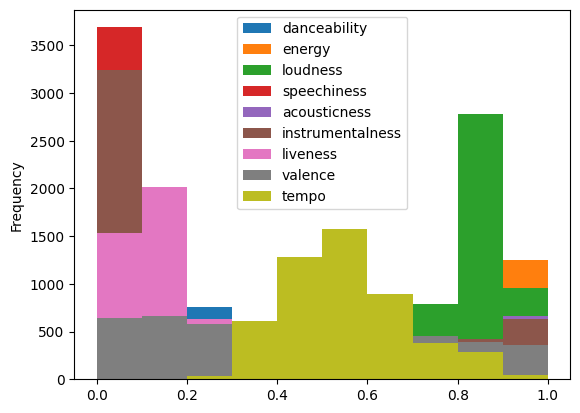

In [ ]:
spotify_df_num_scaled.plot(kind='hist')

## **PCA**

<Axes: >

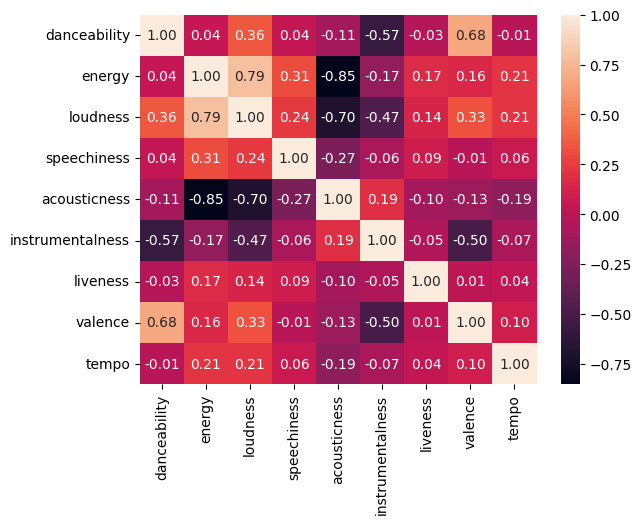

In [ ]:
#sns.heatmap(tips_preproc.corr(), annot=True)

sns.heatmap(spotify_df_num_scaled.corr(), annot=True, fmt='.2f')

In [ ]:
my_pca = PCA()
my_pca

PCA()

In [ ]:
my_pca.fit(spotify_df_num_scaled)

PCA()

In [ ]:
spotify_df_num_scaled_pca = my_pca.transform(spotify_df_num_scaled)
spotify_df_num_scaled_pca

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8
name,,,,,,,,,
Se Eu Quiser Falar Com Deus,0.237005,-0.508321,-0.270269,0.541753,0.588829,0.196275,-0.104646,-0.010597,0.006811
Saudade De Bahia,-0.210510,-0.388092,0.094639,-0.170136,0.023675,0.099399,-0.185879,-0.018369,-0.014450
"Canta Canta, Minha Gente",-0.330664,-0.475087,0.286856,-0.006384,0.026648,-0.141928,0.164576,0.286558,-0.070607
Mulher Eu Sei,0.383165,-0.817680,-0.075781,0.111899,0.212684,0.090633,-0.098783,0.007437,-0.013081
Rosa Morena,0.441767,-0.755688,-0.163251,-0.074703,-0.000346,0.089284,0.018477,-0.005016,-0.062001
...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",1.108853,-0.122749,-0.115636,-0.073023,-0.015392,-0.075151,-0.082858,0.017699,-0.006973
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.911344,-0.220637,-0.320859,-0.088273,-0.040528,-0.112112,-0.103692,0.011600,-0.007652
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",1.404748,0.008037,-0.028241,-0.076840,-0.022218,-0.156775,-0.230264,0.058075,-0.252541


<Axes: ylabel='Frequency'>

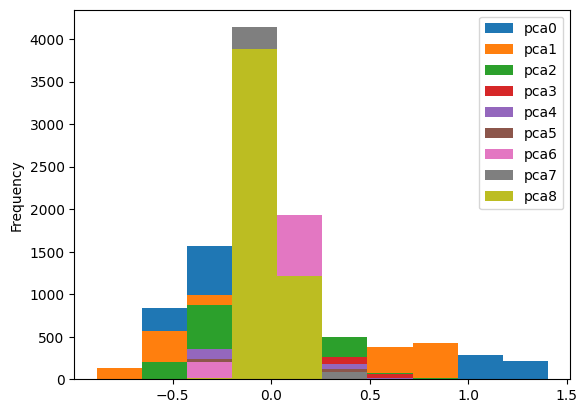

In [ ]:
spotify_df_num_scaled_pca.plot(kind='hist')

In [ ]:
# Get the variance explained by each principal component
explained_variance_array = my_pca.explained_variance_ratio_
explained_variance_array

array([0.45009082, 0.30086303, 0.09943613, 0.0451643 , 0.03730666,
       0.02905942, 0.02433555, 0.0096247 , 0.00411941])

## **Cluster Selection**

**Elbow method**

In [ ]:
pd.DataFrame(explained_variance_array, columns=["Variance explained"])

,Variance explained
0,0.450091
1,0.300863
2,0.099436
3,0.045164
4,0.037307
5,0.029059
6,0.024336
7,0.009625
8,0.004119


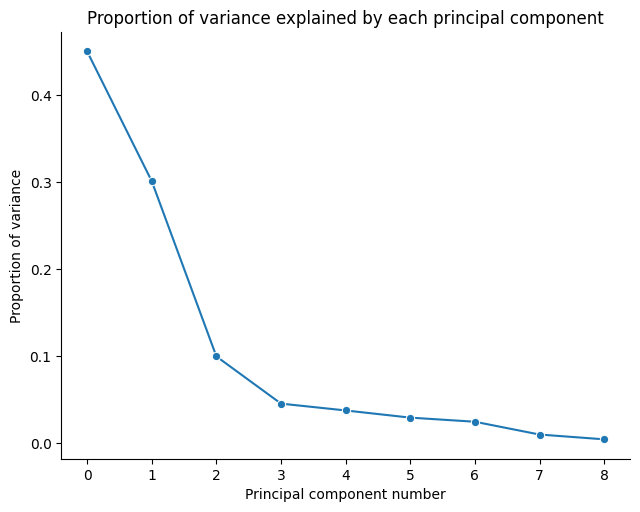

In [ ]:
# Create a Pandas DataFrame from the variance explained array
explained_variance_array_df = pd.DataFrame(explained_variance_array, columns=["Variance explained"])

(
  # Create a line chart with sns.relplot
  sns.relplot(
      kind = 'line',
      data = explained_variance_array_df,
      x = explained_variance_array_df.index,
      y = "Variance explained",
      marker = 'o',
      aspect = 1.3)
  # Set the title of the plot
  .set(title = "Proportion of variance explained by each principal component")
  # Set the axis labels
  .set_axis_labels("Principal component number", "Proportion of variance")
);

In [ ]:
# Set the variable elbow to where you believe the elbow is
elbow = 4

In [ ]:
# Create a PCA object with {elbow} principal components
# We add 1 as the principal components start at 0 and not 1
pca_elbow = PCA(n_components = elbow + 1)

# Fit the PCA object to the scaled features dataframe and transform it
pca_elbow_df = pca_elbow.fit_transform(spotify_df_num_scaled)

# The dataframe now contains the principal components of the scaled features dataframe
pca_elbow_df

,pca0,pca1,pca2,pca3,pca4
name,,,,,
Se Eu Quiser Falar Com Deus,0.237005,-0.508321,-0.270269,0.541753,0.588829
Saudade De Bahia,-0.210510,-0.388092,0.094639,-0.170136,0.023675
"Canta Canta, Minha Gente",-0.330664,-0.475087,0.286856,-0.006384,0.026648
Mulher Eu Sei,0.383165,-0.817680,-0.075781,0.111899,0.212684
Rosa Morena,0.441767,-0.755688,-0.163251,-0.074703,-0.000346
...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",1.108853,-0.122749,-0.115636,-0.073023,-0.015392
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.911344,-0.220637,-0.320859,-0.088273,-0.040528
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",1.404748,0.008037,-0.028241,-0.076840,-0.022218


**Cumulative explained**

In [ ]:
explained_variance_array = my_pca.explained_variance_ratio_
explained_variance_array

array([0.45009082, 0.30086303, 0.09943613, 0.0451643 , 0.03730666,
       0.02905942, 0.02433555, 0.0096247 , 0.00411941])

In [ ]:
cumulative_sum_of_variance = np.cumsum(explained_variance_array)
cumulative_sum_of_variance

array([0.45009082, 0.75095384, 0.85038997, 0.89555427, 0.93286093,
       0.96192035, 0.98625589, 0.99588059, 1.        ])

In [ ]:
# Create a PCA object
pca_variance = PCA(n_components = 0.95)

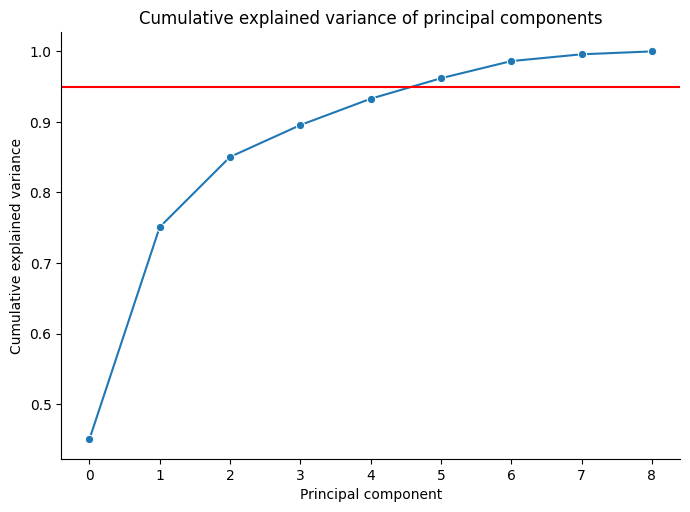

In [ ]:
(
  # Create a cumulative explained variance plot
  sns.relplot(
      kind = "line",  # Create a line plot
      x = range(len(explained_variance_array)),  # Set the x-axis to be the principal component index
      y = cumulative_sum_of_variance,  # Set the y-axis to be the cumulative explained variance
      marker = "o",  # Use a circle marker for the data points
      aspect = 1.4,  # Set the aspect ratio of the plot to be 1.4
  )
  # Set the title of the plot
  .set(title="Cumulative explained variance of principal components")
  # Set the axis labels
  .set_axis_labels("Principal component", "Cumulative explained variance")
);

# Add a horizontal red line at 0.95 on the y axis
plt.axhline(y = 0.95,
            color = 'red');

In [ ]:
# Calculate the cumulative sum
cumulative_sum_of_variance = np.cumsum(explained_variance_array)

# Find the index where the cumulative sum reaches 0.95
index = np.searchsorted(cumulative_sum_of_variance, 0.95)

# Print the number of components required to reach 0.95 variance
print(index + 1)

6


In [ ]:
# We add 1 as the principal components start at 0 and not 1
spotify_num_scaled_pca_index = PCA(n_components = index) # + 1

# Fit the PCA object to the scaled features dataframe and transform it
spotify_num_scaled_pca_index_df = spotify_num_scaled_pca_index.fit_transform(spotify_df_num_scaled)

# The dataframe now contains the principal components of the scaled features dataframe
spotify_num_scaled_pca_index_df

,pca0,pca1,pca2,pca3,pca4
name,,,,,
Se Eu Quiser Falar Com Deus,0.237005,-0.508321,-0.270269,0.541753,0.588829
Saudade De Bahia,-0.210510,-0.388092,0.094639,-0.170136,0.023675
"Canta Canta, Minha Gente",-0.330664,-0.475087,0.286856,-0.006384,0.026648
Mulher Eu Sei,0.383165,-0.817680,-0.075781,0.111899,0.212684
Rosa Morena,0.441767,-0.755688,-0.163251,-0.074703,-0.000346
...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",1.108853,-0.122749,-0.115636,-0.073023,-0.015392
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",0.911344,-0.220637,-0.320859,-0.088273,-0.040528
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",1.404748,0.008037,-0.028241,-0.076840,-0.022218


<Axes: >

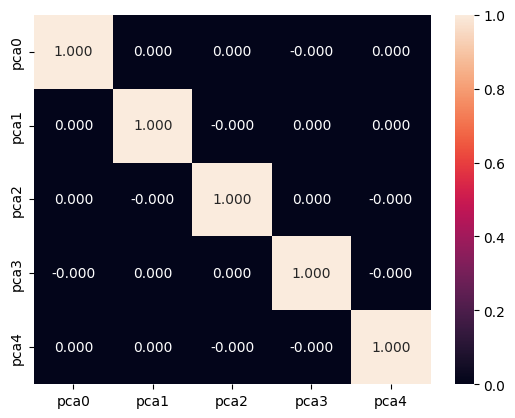

In [ ]:
sns.heatmap(spotify_num_scaled_pca_index_df.corr(), annot=True, fmt='.3f')

## **Model Training**

**Analysing k-means: estimating the numbers of clusters**

In [ ]:
# inertia

# Create an empty list to store the inertia scores
inertia_weighted_sum_within_cluster_distances = []

# Iterate over the range of cluster numbers
for my_clusters in range(20, 100):

    # Create a KMeans object with the specified number of clusters
    my_model = KMeans(n_clusters=my_clusters, random_state=42)

    # Fit the KMeans model to the scaled data
    my_model.fit(spotify_num_scaled_pca_index_df)
    my_inertia = my_model.inertia_
    print(f'a KMEans model with num of clusters {my_clusters} was fitted and get an inertia of {round(my_inertia)}')
    inertia_weighted_sum_within_cluster_distances.append(my_inertia)

a KMEans model with num of clusters 20 was fitted and get an inertia of 296
a KMEans model with num of clusters 21 was fitted and get an inertia of 291
a KMEans model with num of clusters 22 was fitted and get an inertia of 283
a KMEans model with num of clusters 23 was fitted and get an inertia of 276
a KMEans model with num of clusters 24 was fitted and get an inertia of 269
a KMEans model with num of clusters 25 was fitted and get an inertia of 264
a KMEans model with num of clusters 26 was fitted and get an inertia of 259
a KMEans model with num of clusters 27 was fitted and get an inertia of 254
a KMEans model with num of clusters 28 was fitted and get an inertia of 252
a KMEans model with num of clusters 29 was fitted and get an inertia of 248
a KMEans model with num of clusters 30 was fitted and get an inertia of 242
a KMEans model with num of clusters 31 was fitted and get an inertia of 239
a KMEans model with num of clusters 32 was fitted and get an inertia of 234
a KMEans mod

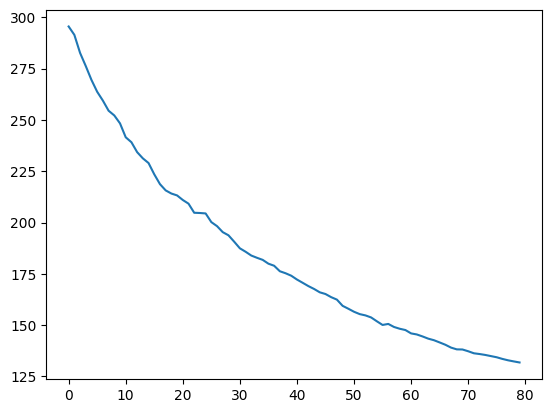

In [ ]:
plt.plot(inertia_weighted_sum_within_cluster_distances)

In [ ]:
KMeans(n_clusters=35)

KMeans(n_clusters=35)

In [ ]:
# silhouette   labels
# Create an empty list to store the silhouette scores
silhouette_weighted_sum_within_cluster_distances = []
# Iterate over the range of cluster numbers
for my_clusters in range(20, 100):
    # Create a KMeans object with the specified number of clusters
    my_model = KMeans(n_clusters= my_clusters, random_state=42)
    # Fit the KMeans model to the scaled data
    my_model.fit(spotify_num_scaled_pca_index_df)
    # Get the cluster labels
    my_labels = my_model.labels_
    # Calculate the silhouette score
    sil_score = silhouette_score(spotify_num_scaled_pca_index_df, my_labels)
    print(f"Clusters: {my_clusters} | Silhouette score: {round(sil_score, 4)}")
    silhouette_weighted_sum_within_cluster_distances.append(sil_score)

Clusters: 20 | Silhouette score: 0.2404
Clusters: 21 | Silhouette score: 0.2275
Clusters: 22 | Silhouette score: 0.225
Clusters: 23 | Silhouette score: 0.2245
Clusters: 24 | Silhouette score: 0.2244
Clusters: 25 | Silhouette score: 0.2194
Clusters: 26 | Silhouette score: 0.2135
Clusters: 27 | Silhouette score: 0.2074
Clusters: 28 | Silhouette score: 0.2043
Clusters: 29 | Silhouette score: 0.2051
Clusters: 30 | Silhouette score: 0.2122
Clusters: 31 | Silhouette score: 0.206
Clusters: 32 | Silhouette score: 0.2084
Clusters: 33 | Silhouette score: 0.2002
Clusters: 34 | Silhouette score: 0.1998
Clusters: 35 | Silhouette score: 0.2004
Clusters: 36 | Silhouette score: 0.2067
Clusters: 37 | Silhouette score: 0.206
Clusters: 38 | Silhouette score: 0.2058
Clusters: 39 | Silhouette score: 0.1964
Clusters: 40 | Silhouette score: 0.1985
Clusters: 41 | Silhouette score: 0.1906
Clusters: 42 | Silhouette score: 0.198
Clusters: 43 | Silhouette score: 0.1908
Clusters: 44 | Silhouette score: 0.1891
Clus

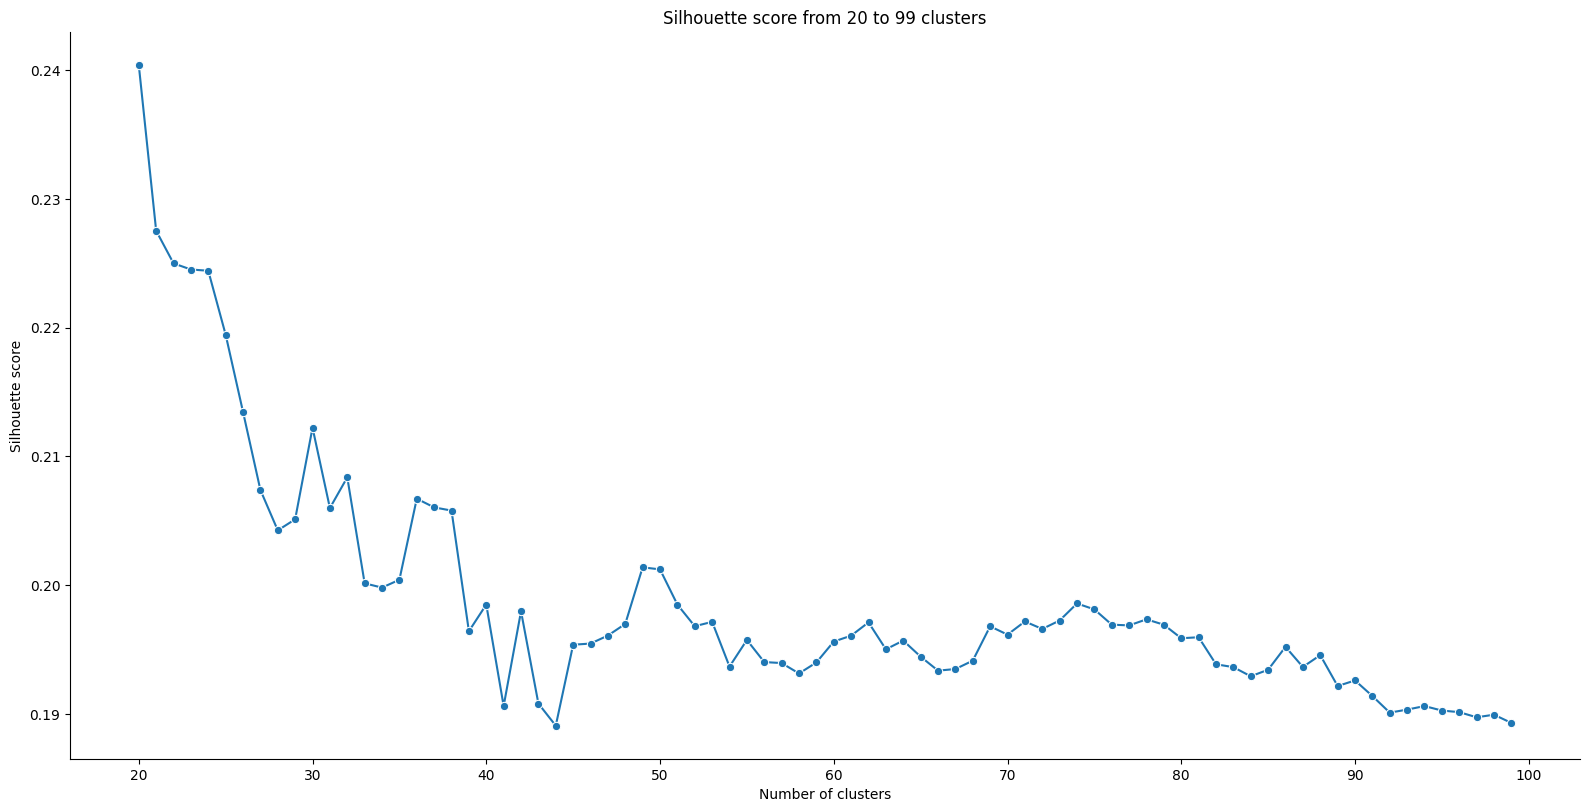

In [ ]:
(sns.relplot(y = silhouette_weighted_sum_within_cluster_distances,
            x = range(20, 100),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 20 to {100 - 1} clusters")
.set_axis_labels("Number of clusters", "Silhouette score")
);

In [ ]:
KMeans(n_clusters=35)

KMeans(n_clusters=35)

**KMeans**

In [ ]:
model_best = KMeans(n_clusters=43, random_state=42)
model_best.fit(spotify_num_scaled_pca_index_df)
spotify_df['playlist_#'] = model_best.labels_
spotify_df

,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,html,playlist_#
name,,,,,,,,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.6580,0.25900,-13.141,0.0705,0.694,0.000059,0.9750,0.3060,110.376,,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...,20
Saudade De Bahia,Antônio Carlos Jobim,0.7420,0.39900,-12.646,0.0346,0.217,0.000002,0.1070,0.6930,125.039,,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...,13
"Canta Canta, Minha Gente",Martinho Da Vila,0.8510,0.73000,-11.048,0.3470,0.453,0.000063,0.1240,0.9050,93.698,,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...,37
Mulher Eu Sei,Chico César,0.7050,0.05020,-18.115,0.0471,0.879,0.000041,0.3860,0.5240,106.802,,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...,41
Rosa Morena,Kurt Elling,0.6510,0.11900,-19.807,0.0380,0.916,0.000343,0.1040,0.4020,120.941,,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,0.2020,0.06940,-23.390,0.0473,0.917,0.715000,0.0832,0.0655,87.906,,1aEhYlZtypmipA06SDJ4U3,https://open.spotify.com/track/1aEhYlZtypmipA0...,0
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,0.1880,0.10100,-21.873,0.0442,0.855,0.426000,0.0694,0.0355,83.134,,1Gfqe7TAKklmuZf6hxsH6h,https://open.spotify.com/track/1Gfqe7TAKklmuZf...,5
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,0.0596,0.00093,-42.959,0.0434,0.951,0.969000,0.0772,0.0344,71.573,,2XNwnFrdMDpismp0VUZ7cU,https://open.spotify.com/track/2XNwnFrdMDpismp...,0


In [ ]:
playlist_counts = spotify_df['playlist_#'].value_counts()#.sort_index()
print("Songs per playlist:")
print(playlist_counts)

Songs per playlist:
playlist_#
15    232
0     224
36    201
29    195
40    186
1     186
3     183
32    180
10    168
2     167
11    166
24    162
37    151
5     151
18    147
13    144
12    127
41    121
35    119
38    119
8     115
16    114
23    114
19    107
4     107
26    106
42    103
27    102
25     99
21     90
22     83
33     80
30     68
17     65
7      63
6      62
28     56
39     56
9      53
34     48
31     44
20     26
14     24
Name: count, dtype: int64


In [ ]:
for playlist_num, group in spotify_df.groupby('playlist_#'):
    print(f"\n==== PLAYLIST #{playlist_num} ====")
    display(group.head(5))


==== PLAYLIST #0 ====


,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,html,playlist_#
name,,,,,,,,,,,,,,
Sigur 1 (Untitled),Sigur Rós,0.294,0.12700,-13.916,0.0332,0.915,0.763,0.0724,0.0400,85.423,,45X6BMb7ONA5GPJTdWU1jr,https://open.spotify.com/track/45X6BMb7ONA5GPJ...,0
Two Skies,Dirk Maassen,0.369,0.19800,-16.388,0.0483,0.970,0.930,0.1090,0.0470,126.200,,1zvyfRhIzjJepYbxxQa6v6,https://open.spotify.com/track/1zvyfRhIzjJepYb...,0
I. Adagio sostenuto,Ludwig van Beethoven,0.141,0.00123,-43.851,0.0429,0.994,0.942,0.1100,0.0843,78.155,,4tQoPPpXKILHrBO9w3dnLr,https://open.spotify.com/track/4tQoPPpXKILHrBO...,0
Someone You Loved,The Piano Guys,0.270,0.18400,-14.681,0.0359,0.983,0.940,0.1070,0.1100,99.428,,0PiNYPMkmHxtDS0EZKK35X,https://open.spotify.com/track/0PiNYPMkmHxtDS0...,0
Air on a G String,Johann Sebastian Bach,0.109,0.31400,-11.270,0.0390,0.982,0.895,0.1080,0.0557,172.773,,0mD1a7haZKdX9I0oPywrMb,https://open.spotify.com/track/0mD1a7haZKdX9I0...,0



==== PLAYLIST #1 ====


,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,html,playlist_#
name,,,,,,,,,,,,,,
Carnaval Inesquecível Na Cidade Alta,Mundo Livre S/A,0.746,0.557,-9.756,0.0609,0.05190,0.00188,0.0530,0.693,150.165,,4lnLWhIiUKxq4Rh898vkVk,https://open.spotify.com/track/4lnLWhIiUKxq4Rh...,1
Agua De Beber,Sophie Milman,0.660,0.759,-8.550,0.0437,0.24300,0.00227,0.0756,0.700,94.477,,4ic2XfSYoMch7DrdNf2T3N,https://open.spotify.com/track/4ic2XfSYoMch7Dr...,1
Alegria,Batida,0.715,0.691,-8.953,0.0869,0.00331,0.21800,0.1320,0.747,136.015,,1K3JwmUeXS2g8OpRhtxtDO,https://open.spotify.com/track/1K3JwmUeXS2g8Op...,1
I Wish You Were Here,Alpha Blondy,0.796,0.566,-7.857,0.0695,0.02000,0.01810,0.1160,0.580,143.994,,4AVIdds2A4E4UsZcVU0Uso,https://open.spotify.com/track/4AVIdds2A4E4UsZ...,1
Dusty Men,Saule,0.655,0.840,-4.204,0.0471,0.01160,0.00542,0.1410,0.630,108.940,,1WUCUeB6bvoio4oi1AZtZu,https://open.spotify.com/track/1WUCUeB6bvoio4o...,1



==== PLAYLIST #2 ====


...

,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,html,playlist_#
name,,,,,,,,,,,,,,
Under Your Spell,Desire,0.572,0.599,-10.190,0.0334,0.027700,0.649,0.0938,0.474,105.555,,38vNwoJygRx1u77aJOV8Zb,https://open.spotify.com/track/38vNwoJygRx1u77...,33
"Que No Sea Kang, Por Favor",Los Planetas,0.435,0.494,-9.032,0.0279,0.000228,0.854,0.1600,0.228,93.997,,41OGvdfzThkNxQVUkkWgq9,https://open.spotify.com/track/41OGvdfzThkNxQV...,33
A New Error,Moderat,0.719,0.461,-11.338,0.0370,0.029800,0.801,0.0634,0.104,110.991,,6OGRM4MAOlyOdhHuX0OJ6P,https://open.spotify.com/track/6OGRM4MAOlyOdhH...,33
Let’s Explode,Clem Snide,0.379,0.492,-7.451,0.0265,0.073100,0.587,0.3460,0.222,104.520,,3bdi228j2POsaAx8YMfi3Y,https://open.spotify.com/track/3bdi228j2POsaAx...,33
Just Like Honey,The Jesus and Mary Chain,0.341,0.552,-10.503,0.0423,0.000080,0.616,0.0591,0.486,121.361,,1LwP9g1Hjbs64jXM2Qsxry,https://open.spotify.com/track/1LwP9g1Hjbs64jX...,33



==== PLAYLIST #34 ====


,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,html,playlist_#
name,,,,,,,,,,,,,,
Waterfall,The Fresh & Onlys,0.283,0.899,-1.325,0.0383,0.041000,0.944,0.691,0.612,86.862,,4Uxz2P0dDnFJFi4rb4Awvr,https://open.spotify.com/track/4Uxz2P0dDnFJFi4...,34
Girl,Jamie xx,0.511,0.610,-11.291,0.2430,0.163000,0.610,0.744,0.482,101.614,,4QFEUktWf0JfhpFr2RZc8A,https://open.spotify.com/track/4QFEUktWf0JfhpF...,34
Sophia So Far,Goodnight Radio,0.446,0.890,-7.974,0.0308,0.270000,0.661,0.451,0.484,170.002,,6bNjJfq9oQGnqicO0iphsa,https://open.spotify.com/track/6bNjJfq9oQGnqic...,34
Half Bad,White Reaper,0.157,0.979,-3.972,0.0819,0.000086,0.810,0.594,0.227,84.190,,2co19l4ffKkkJtCPDrhGWr,https://open.spotify.com/track/2co19l4ffKkkJtC...,34
For Kate I Wait,Ariel Pink,0.176,0.754,-8.753,0.1940,0.251000,0.779,0.459,0.567,160.260,,1moLbyHuk25GO18QxdBaMj,https://open.spotify.com/track/1moLbyHuk25GO18...,34



==== PLAYLIST #35 ====


,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,html,playlist_#
name,,,,,,,,,,,,,,
Dualize,L.A.,0.520,0.843,-4.157,0.0352,0.078400,0.025400,0.174,0.630,133.016,,2PIC7KxAgHGYCGuGqcorw7,https://open.spotify.com/track/2PIC7KxAgHGYCGu...,35
Baby Lee,Teenage Fanclub,0.419,0.856,-5.443,0.0298,0.009280,0.096400,0.124,0.721,152.009,,5mt3HpjZuJNpqg1k415CnR,https://open.spotify.com/track/5mt3HpjZuJNpqg1...,35
Your Fucking Sunny Day,Lambchop,0.532,0.912,-3.366,0.0360,0.043000,0.010400,0.232,0.715,142.495,,3ZORmtq9HSYhdiyeeJyKHb,https://open.spotify.com/track/3ZORmtq9HSYhdiy...,35
King Of The Beach,Wavves,0.367,0.973,-2.191,0.0985,0.000428,0.000015,0.370,0.617,170.043,,6Jyi5nq9lvIQLEOCbv1s3Y,https://open.spotify.com/track/6Jyi5nq9lvIQLEO...,35
Just Like Heaven,The Cure,0.445,0.975,-3.418,0.0482,0.019000,0.000077,0.136,0.754,151.094,,7JM85ZtL4IvNOmCFzWtKPS,https://open.spotify.com/track/7JM85ZtL4IvNOmC...,35


In [ ]:
spotify_df[spotify_df['playlist_#'] == 33]

,artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,html,playlist_#
name,,,,,,,,,,,,,,
Under Your Spell,Desire,0.572,0.599,-10.190,0.0334,0.027700,0.649,0.0938,0.474,105.555,,38vNwoJygRx1u77aJOV8Zb,https://open.spotify.com/track/38vNwoJygRx1u77...,33
"Que No Sea Kang, Por Favor",Los Planetas,0.435,0.494,-9.032,0.0279,0.000228,0.854,0.1600,0.228,93.997,,41OGvdfzThkNxQVUkkWgq9,https://open.spotify.com/track/41OGvdfzThkNxQV...,33
A New Error,Moderat,0.719,0.461,-11.338,0.0370,0.029800,0.801,0.0634,0.104,110.991,,6OGRM4MAOlyOdhHuX0OJ6P,https://open.spotify.com/track/6OGRM4MAOlyOdhH...,33
Let’s Explode,Clem Snide,0.379,0.492,-7.451,0.0265,0.073100,0.587,0.3460,0.222,104.520,,3bdi228j2POsaAx8YMfi3Y,https://open.spotify.com/track/3bdi228j2POsaAx...,33
Just Like Honey,The Jesus and Mary Chain,0.341,0.552,-10.503,0.0423,0.000080,0.616,0.0591,0.486,121.361,,1LwP9g1Hjbs64jXM2Qsxry,https://open.spotify.com/track/1LwP9g1Hjbs64jX...,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
The Holocaust Incarnate,Aborted,0.371,0.828,-6.536,0.0763,0.000077,0.559,0.0947,0.508,115.760,,0jJH8QONmQd1L8bv4dejGZ,https://open.spotify.com/track/0jJH8QONmQd1L8b...,33
Captain Howdy,Broken Hope,0.328,0.646,-12.344,0.0438,0.001330,0.891,0.1470,0.477,82.433,,5DEGOuhmKzL6RlNSMFGvXp,https://open.spotify.com/track/5DEGOuhmKzL6RlN...,33
Jesus Is Dead!,Altar,0.420,0.910,-10.411,0.1260,0.004220,0.724,0.1170,0.267,102.359,,5MtzKEgC2G8HMFGptFGic0,https://open.spotify.com/track/5MtzKEgC2G8HMFG...,33


In [ ]:
spotify_df['artist'].value_counts(normalize=False).sort_values(ascending=False)

,count
artist,
Death,29
Obituary,29
Morbid Angel,26
Deicide,26
Cannibal Corpse,24
...,...
Carl Nielsen,1
Per Nørgård,1
Nikolai Rimsky-Korsakov,1
